# Prediction market simulation (DeGroot + price feedback)

Use this notebook to tune **θ**, source noise, **trader attention / β weights / deadbands**, and **market depth γ**, then inspect **π(t)** and beliefs. Core model code lives in the `prediction_market` package beside this folder.


In [1]:
# Setup: path, imports, RNG
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from prediction_market import Market, PredictionMarketSimulation, SourceLayer, Trader

SEED = 7
rng = np.random.default_rng(SEED)


## Parameters

Edit the next cell: **ground truth θ**, number of sources **K** and traders **N**, noise **σ**, per-trader **w**, **λ** (arrival weights), **α** (deadband), **β_info / β_price**, and market **γ**. Traders start with **Uniform(0,1)** initial beliefs. Then change `N_STEPS` and re-run.

The following cell draws the **tripartite graph** (sources → traders ⇄ market); run it after the parameters cell so `W`, `K`, `N`, and `initial_beliefs` exist.


final pi: 0.7250516033359958 theta: 1 frac traded: 0.06375


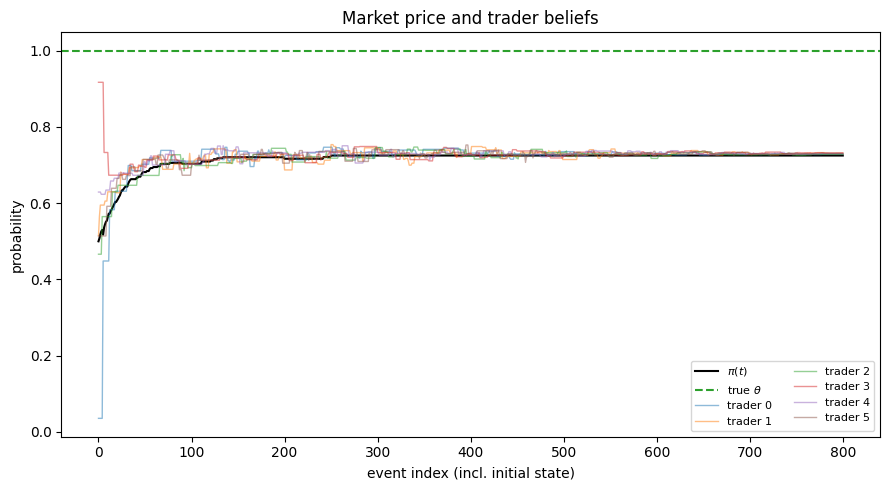

In [2]:
# --- knobs ---
RESOLUTION_DECAY = True  # σ → 0 linearly by last step; set False for constant noise

THETA = 1  # true outcome 0 or 1
K = 4
N = 6
N_STEPS = 800

# sources: s_j = theta + mu_j + Normal(0, sigma_j^2)
mu = np.linspace(-0.05, 0.1, K)
noise_std = np.full(K, 0.4)

# traders: random nonnegative attention, normalized; initial beliefs Uniform(0, 1)
W = rng.random((N, K))
W = W / W.sum(axis=1, keepdims=True)
initial_beliefs = rng.uniform(0.0, 1.0, size=N)

traders = [
    Trader(
        w=W[i],
        a=0.8 + 0.2 * i,
        lam=1.0,
        alpha=0.03,
        beta_info=0.35,
        beta_price=0.35,
        belief0=float(initial_beliefs[i]),
    )
    for i in range(N)
]

sources = SourceLayer(mu=mu, noise_std=noise_std, resolution_decay=RESOLUTION_DECAY)
market = Market(gamma=0.12, pi0=0.5)
sim = PredictionMarketSimulation(THETA, sources, traders, market, rng=rng)

res = sim.run(N_STEPS)
print("final pi:", float(res.pi[-1]), "theta:", int(res.theta), "frac traded:", res.traded.mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(res.pi, label=r"$\pi(t)$", color="black")
ax.axhline(THETA, color="tab:green", ls="--", label=r"true $\theta$")
for i in range(N):
    ax.plot(res.beliefs[:, i], alpha=0.5, lw=1.0, label=f"trader {i}")
ax.set_xlabel("event index (incl. initial state)")
ax.set_ylabel("probability")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.set_title("Market price and trader beliefs")
plt.tight_layout()
plt.show()


### Same results with `resolution_decay` on vs off?

If you had **two copies** of the simulation cell (one with `True`, one with `False`), **running both in order** leaves whatever ran **last** in `res` and on the plot — so it looked like the toggle did nothing.

Use **`RESOLUTION_DECAY`** at the top of the **single** parameters cell above, then **re-run that cell** (or **Kernel → Restart & Run All**). Do not duplicate the full run cell.

Even with a single cell, paths can look similar when **`β_price` and prior weight are large** (price/prior dampen how much per-step signal noise matters), but you should still see **different** `final pi` and traces when comparing runs with the same seed and only `RESOLUTION_DECAY` flipped.


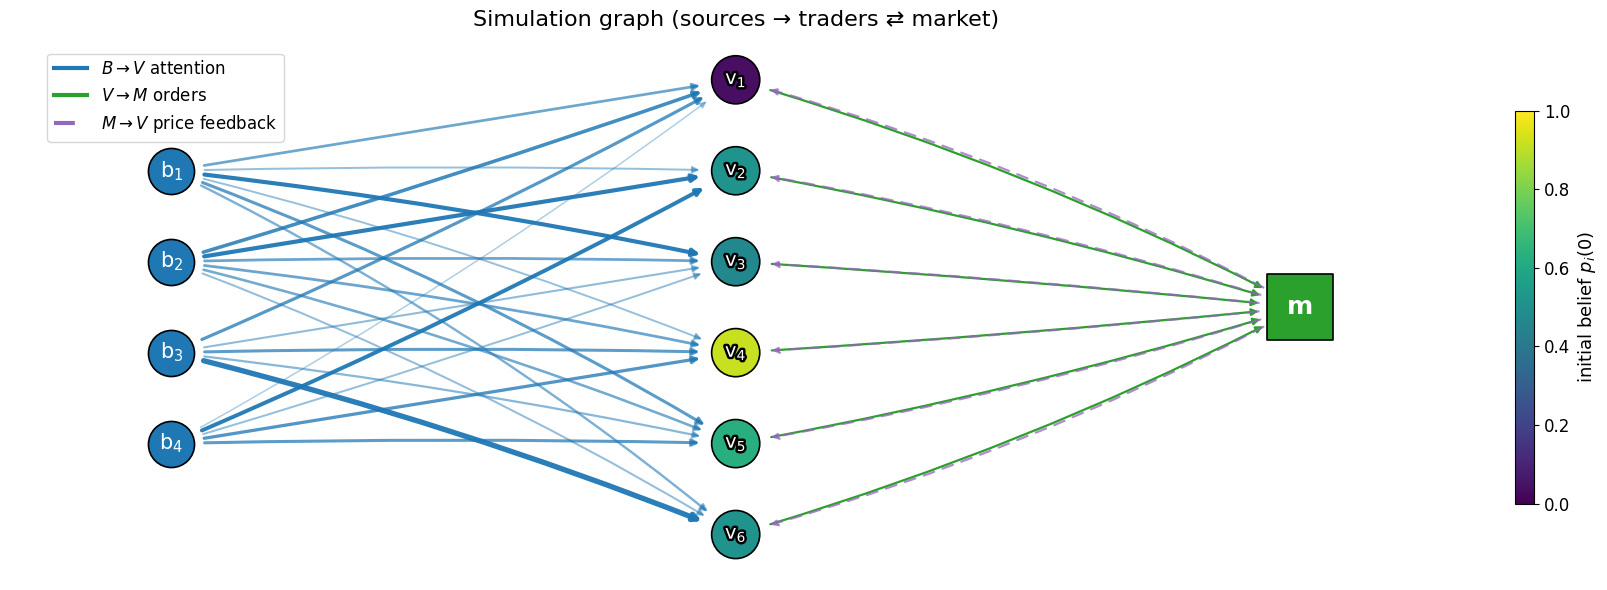

In [3]:
# Tripartite graph: B → V (attention, width ∝ w_ij), V → M (orders), M ⇝ V (price feedback, dashed)
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

_w_thresh = max(0.03, 0.12 * float(W.max()))

# Wide layout: do NOT use equal aspect — it squeezes x when the graph is tall.
fig_w, fig_h = 18, max(6.0, 0.55 * max(K, N) + 2.2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
scale_y = 3.6
xb, xv, xm = 0.0, 14.0, 28.0
yb = np.array([0.0]) if K == 1 else np.linspace((K - 1) / 2, -(K - 1) / 2, K) * scale_y
yv = np.array([0.0]) if N == 1 else np.linspace((N - 1) / 2, -(N - 1) / 2, N) * scale_y

for i in range(N):
    for j in range(K):
        w = float(W[i, j])
        if w < _w_thresh:
            continue
        rad = 0.12 * (j - i) / max(K + N, 4)
        ax.annotate(
            "",
            xy=(xv, yv[i]),
            xytext=(xb, yb[j]),
            arrowprops={
                "arrowstyle": "-|>",
                "color": "tab:blue",
                "alpha": float(min(0.95, 0.2 + 1.8 * w)),
                "lw": float(0.6 + 5.5 * w),
                "shrinkA": 24,
                "shrinkB": 26,
                "connectionstyle": f"arc3,rad={rad}",
            },
        )

for i in range(N):
    rad = 0.12 * (i - (N - 1) / 2) / max(N, 1)
    ax.annotate(
        "",
        xy=(xm, 0),
        xytext=(xv, yv[i]),
        arrowprops={
            "arrowstyle": "-|>",
            "color": "tab:green",
            "lw": 1.6,
            "shrinkA": 26,
            "shrinkB": 30,
            "connectionstyle": f"arc3,rad={rad}",
        },
    )

for i in range(N):
    rad = -0.14 * (i - (N - 1) / 2) / max(N, 1)
    ax.annotate(
        "",
        xy=(xv, yv[i]),
        xytext=(xm, 0),
        arrowprops={
            "arrowstyle": "-|>",
            "color": "tab:purple",
            "lw": 1.6,
            "ls": (0, (5, 4)),
            "alpha": 0.75,
            "shrinkA": 30,
            "shrinkB": 26,
            "connectionstyle": f"arc3,rad={rad}",
        },
    )

ax.scatter(np.full(K, xb), yb, s=1100, c="#1f77b4", zorder=4, edgecolors="black", linewidths=1.2)
for j in range(K):
    ax.text(
        xb,
        yb[j],
        f"b$_{j+1}$",
        ha="center",
        va="center",
        fontsize=15,
        color="white",
        zorder=5,
    )

sc = ax.scatter(
    np.full(N, xv),
    yv,
    s=1200,
    c=initial_beliefs,
    cmap="viridis",
    vmin=0,
    vmax=1,
    zorder=4,
    edgecolors="black",
    linewidths=1.2,
)
for i in range(N):
    ax.text(
        xv,
        yv[i],
        f"v$_{i+1}$",
        ha="center",
        va="center",
        fontsize=14,
        color="white",
        zorder=5,
        path_effects=[pe.withStroke(linewidth=3.5, foreground="black")],
    )

ax.scatter([xm], [0], s=2200, c="#2ca02c", marker="s", zorder=4, edgecolors="black", linewidths=1.2)
ax.text(xm, 0, "m", ha="center", va="center", fontsize=18, fontweight="bold", color="white", zorder=5)

ax.set_aspect("auto")
ax.axis("off")
margin_x, margin_y = 4.0, 1.8
ax.set_xlim(xb - margin_x, xm + margin_x)
ax.set_ylim(
    min(float(yb.min()), float(yv.min()), -1) - margin_y,
    max(float(yb.max()), float(yv.max()), 1) + margin_y,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.72, pad=0.03)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r"initial belief $p_i(0)$", fontsize=13)

legend_elems = [
    Line2D([0], [0], color="tab:blue", lw=3, label=r"$B\to V$ attention"),
    Line2D([0], [0], color="tab:green", lw=3, label=r"$V\to M$ orders"),
    Line2D([0], [0], color="tab:purple", lw=3, ls=(0, (5, 4)), label=r"$M\to V$ price feedback"),
]
ax.legend(handles=legend_elems, loc="upper left", bbox_to_anchor=(0.02, 0.98), fontsize=12)
ax.set_title("Simulation graph (sources → traders ⇄ market)", fontsize=16)
plt.tight_layout()
plt.show()

## Results

After changing parameters, jot short notes here (what moved π, who traded first, convergence vs oscillation).


active traders: [0, 1, 2, 3, 4, 5]
D (rows sum not necessarily 1 — off-diagonals are price-mediated weights):
 [[0.3   0.07  0.059 0.05  0.044 0.039]
 [0.088 0.3   0.059 0.05  0.044 0.039]
 [0.088 0.07  0.3   0.05  0.044 0.039]
 [0.088 0.07  0.059 0.3   0.044 0.039]
 [0.088 0.07  0.059 0.05  0.3   0.039]
 [0.088 0.07  0.059 0.05  0.044 0.3  ]]


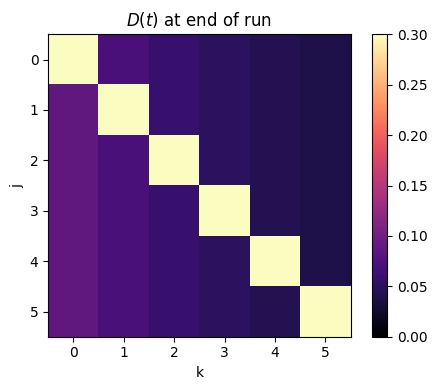

In [4]:
# Peer-influence matrix D(t) for traders who have traded at least once (see model PDF)
active = {int(i) for i in np.where(res.active_mask[-1] > 0)[0]}
D = sim.peer_influence_matrix(active)
print("active traders:", sorted(active))
print("D (rows sum not necessarily 1 — off-diagonals are price-mediated weights):\n", np.round(D, 3))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(D, cmap="magma", vmin=0, vmax=max(D.max(), 1e-6))
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xlabel("k")
ax.set_ylabel("j")
ax.set_title(r"$D(t)$ at end of run")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## Next steps

- Call `sim.reset()` then `sim.run(...)` for another path with the same objects. (`reset()` sets every trader belief back to **0.5**; re-run the parameters cell if you want fresh **Uniform(0,1)** starts.)
- Add correlated source noise via `SourceLayer(..., cov=Sigma)`.
- Log per-step `q` or extend `SimulationResult` if you need finer diagnostics.
